In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yapss
from yapss import math
import sympy as sp

problem = yapss.Problem(name="Simple_Cycler", nx=[6], nd = 3, nq = [1], nu = [3])
mu = 1.2150584270572e-2

In [2]:
def U_derivs():
    x, y, z = sp.symbols('x y z', real = True)

    r1 = sp.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = sp.sqrt((x - 1 + mu)**2 + y**2 + z**2)

    U = -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

    Ux  = sp.diff(U, x)
    Uy  = sp.diff(U, y)
    Uz = sp.diff(U, z)

    Uxx = sp.diff(Ux, x)
    Uxy = sp.diff(Ux, y)
    Uyy = sp.diff(Uy, y)

    U_f = sp.lambdify((x, y, z), U, "numpy")
    Ux_f = sp.lambdify((x, y, z), Ux, "numpy")
    Uy_f = sp.lambdify((x, y, z), Uy, "numpy")
    Uz_f = sp.lambdify((x, y, z), Uz, "numpy")
    Uxx_f = sp.lambdify((x, y, z), Uxx, "numpy")
    Uxy_f = sp.lambdify((x, y, z), Uxy, "numpy")
    Uyy_f = sp.lambdify((x, y, z), Uyy, "numpy")

    return U_f, Ux_f, Uy_f, Uz_f, Uxx_f, Uxy_f, Uyy_f

U, Ux, Uy, Uz, Uxx, Uxy, Uyy = U_derivs()

C_value = 3.151175879508174
W_cf = 10
W_c = 0
W_u = 1
W_theta = 1

theta = math.pi/4
phi = theta/2

In [3]:
def objective(arg):
    xf, yf, zf, vxf, vyf, vzf = arg.phase[0].final_state
    Cf = -2*U(xf, yf, zf) - (vxf**2 + vyf**2 + vzf**2)
    arg.objective = W_cf*(Cf - C_value)**2 + arg.phase[0].integral[0]

def continuous(arg):
    ux, uy, uz = arg.phase[0].control
    x, y, z, vx, vy, vz = arg.phase[0].state
    vx = vx + ux
    vy = vy + uy
    vz = vz + uz

    r1 = math.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = math.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    ax = x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3 + 2*vy
    ay = y - (1 - mu)*y/r1**3 - mu*y/r2**3 - 2*vx
    az = -(1 - mu)*z/r1**3 - mu*z/r2**3

    C = -2*U(x, y, z) - (vx**2 + vy**2 + vz**2)

    arg.phase[0].dynamics = [vx, vy, vz, ax, ay, az]
    arg.phase[0].integrand = W_c*(C - C_value)**2 + W_u*(ux**2 + uy**2 + uz**2) + W_theta*(math.mod(math.atan2(z,y), math.pi) - theta)**2

def discrete(arg):
    xi, yi, zi, _, _, _ = arg.phase[0].initial_state
    xf, yf, zf, _, _, _ = arg.phase[0].final_state
    arg.discrete = [xf-xi, yf-yi, zf-zi]

In [4]:
problem.functions.objective = objective
problem.functions.continuous = continuous
problem.functions.discrete = discrete

In [5]:
# def y_dot_initial(x, y, z, C):
#     return -math.sqrt(-2*U(x, y, z) - C)

# x_guess = -0.767856324800
# z_guess = 0
# zdot_guess = 0
# initial_guess = np.array([x_guess, 0, z_guess, 0, y_dot_initial(x_guess, 0, z_guess, C_value), zdot_guess])

In [6]:
def day_to_gen(t):
    return t*2*math.pi/27.321661
def gen_to_day(t):
    return t*27.321661/2/math.pi

In [7]:
guess_sol = np.load("3dorbit.npz")
state_guess = guess_sol["state"]
for i in range (np.size(state_guess, 1)):
    xs, ys, zs, vxs, vys, vzs = state_guess[:,i]
    xsf = xs
    ysf = ys - 2*ys*math.sin(phi)**2
    zsf = 2*ys*math.sin(phi)*math.cos(phi)
    vxsf = vxs
    vysf = vys - 2*vys*math.sin(phi)**2
    vzsf = 2*vys*math.sin(phi)*math.cos(phi)
    state_guess[:,i] = [xsf, ysf, zsf, vxsf, vysf, vzsf]

time_guess = guess_sol["time"]
control_guess = guess_sol["control"]
for i in range (np.size(control_guess, 1)):
    xs, ys, zs = control_guess[:, i]
    xsf = xs
    ysf = ys - 2*ys*math.sin(phi)**2
    zsf = 2*ys*math.sin(phi)*math.cos(phi)
    control_guess[:,i] = [xsf, ysf, zsf]

time_c_guess = guess_sol["time_c"]

phase = problem.guess.phase[0]
phase.time = time_guess
phase.state = state_guess
phase.control = control_guess

In [8]:
x, y, z, vx, vy, vz = state_guess
np.min(math.atan2(z,y)%math.pi)
np.min(math.atan2(vz,vy)%math.pi)

np.float64(0.7853981633974482)

In [9]:
bounds = problem.bounds.phase[0]
bounds.initial_time.lower = bounds.initial_time.upper = 0
problem.bounds.discrete.lower = problem.bounds.discrete.upper = [0, 0, 0]
bounds.initial_state.lower[[1,2,3]] = bounds.initial_state.upper[[1,2,3]] = bounds.final_state.lower[[1,2,3]] = bounds.final_state.upper[[1,2,3]] = [0, 0, 0]
bounds.final_time.lower = 1
bounds.control.lower = [-1, -1, -1]
bounds.control.upper = [1, 1, 1]

In [10]:
problem.derivatives.method = "auto"
problem.derivatives.order = "second"
problem.spectral_method = "lgl"
segments, points = 100, 10
problem.mesh.phase[0].collocation_points = segments*[points]
problem.mesh.phase[0].fraction = segments*[1/segments]

In [11]:
problem.ipopt_options.mu_strategy = "adaptive"
problem.ipopt_options.print_level = 3
problem.ipopt_options.print_user_options = "yes"
problem.ipopt_options.timing_statistics = "yes"
problem.ipopt_options.sb = "yes"
problem.ipopt_options.tol = 1e-20

In [12]:
import winsound

In [13]:
solution = problem.solve()
winsound.Beep(440, 500)
winsound.Beep(440, 500)

In [14]:
state = solution.phase[0].state
time = solution.phase[0].time
control = solution.phase[0].control
time_c = solution.phase[0].time_c
t0 = solution.phase[0].initial_time
tf = solution.phase[0].final_time
x, y, z, vx, vy, vz = state
print("Orbit Period (nondimensional time)", tf)
print("Difference in final x velocity", vx[0] - vx[-1])
print("Difference in final y velocity", vy[0] - vy[-1])
print("Difference in final z velocity", vz[0] - vz[-1])

Orbit Period (nondimensional time) 5.815180911603835
Difference in final x velocity 0.0
Difference in final y velocity 0.03377105401466197
Difference in final z velocity 0.07236776182734828


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Maximum Z Error 0.18504639504753792


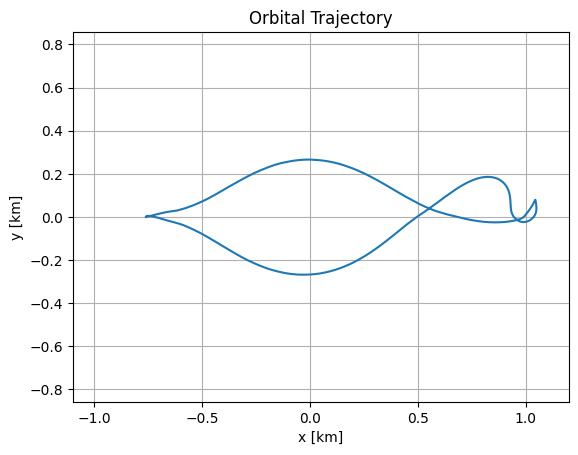

In [15]:
plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.grid(True)
z_err = np.max(np.abs(z)) # Maximum z error
print("Maximum Z Error", z_err)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


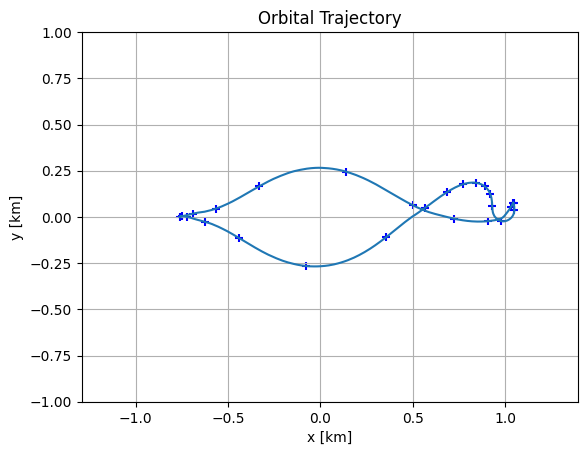

In [16]:
t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)

plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.scatter(x_ticks, y_ticks, marker='+', color='blue')
plt.grid(True)

In [17]:
print("Error [seconds]", abs(gen_to_day(tf) - 44.7538)*24*60*60)       # seconds off from period stated in paper
print("Error [%]", abs(gen_to_day(tf) - 44.7538)/44.7538*100)  # days off expressed as a percent

Error [seconds] 1681965.9709273956
Error [%] 43.49842636286885


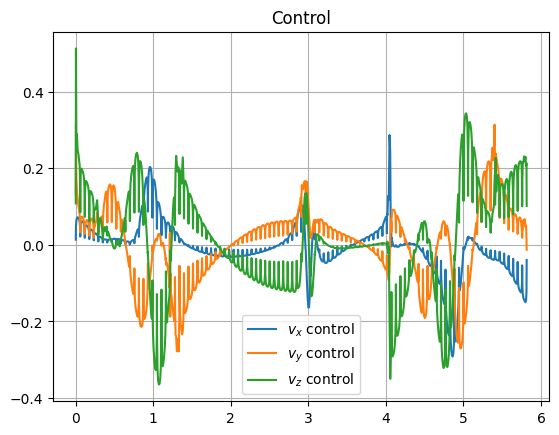

In [18]:
plt.figure()
plt.plot(time_c, control[0], time_c, control[1], time_c, control[2])
plt.title("Control")
plt.legend(["$v_x$ control", "$v_y$ control", "$v_z$ control"])
plt.grid(True)

In [19]:
C_vals = np.zeros((len(x), 1))
for i in range (len(x)):
    C_vals[i] = -2*U(x[i], y[i], z[i]) - (vx[i]**2 + vy[i]**2 + vz[i]**2)
C_err = np.ptp(C_vals) # Maximum Jacobi constant deviation
print("Maximum Jacobi Constant Deviation", C_err)

Maximum Jacobi Constant Deviation 1.294387630594802


Average Jacobi Constant 2.9916526353340496


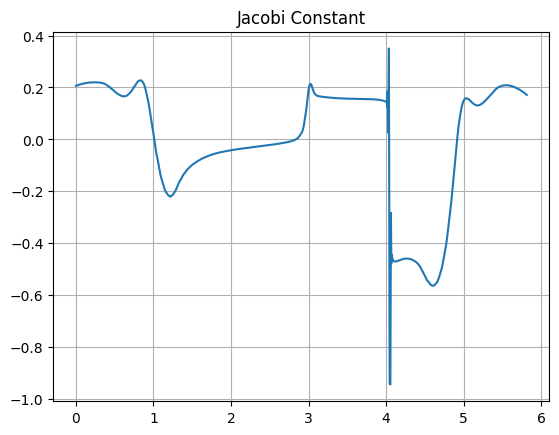

In [20]:
C_mean = np.mean(C_vals)
print("Average Jacobi Constant", C_mean)
plt.figure()
plt.plot(time, (C_vals - C_mean))
plt.title("Jacobi Constant")
plt.grid(True)

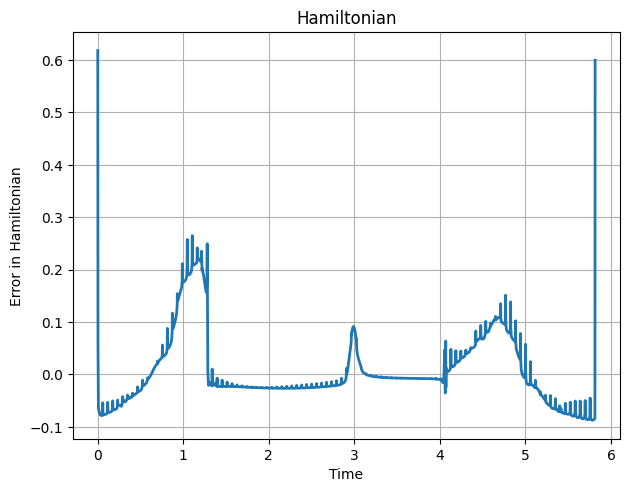

Maximum Hamiltonian Deviation 0.7052637878183433


In [21]:
hamiltonian = solution.phase[0].hamiltonian

plt.figure()
plt.plot(time, hamiltonian, linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"Error in Hamiltonian")
plt.tight_layout()
plt.title("Hamiltonian")
plt.autoscale(axis='y')
plt.grid(True)
plt.show()

hamil_dev = np.ptp(hamiltonian)
print("Maximum Hamiltonian Deviation", hamil_dev)

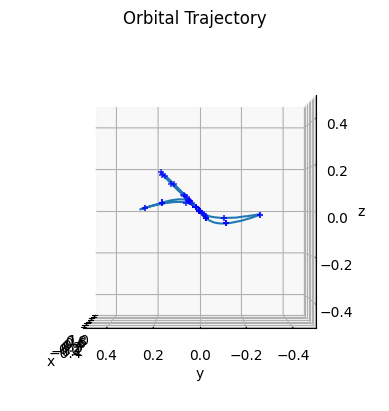

In [23]:
t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")
fz = interp1d(time, z, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)
z_ticks = fz(t_tick)

fig_3d = plt.figure()
ax = fig_3d.add_subplot(111, projection='3d')
plt.plot(x, y, z)
ax.set_box_aspect([1, 1, 1])
ax.set_xlim([-0.5, 1])
ax.set_ylim([-0.5, 0.5])
ax.set_zlim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.scatter3D(x_ticks, y_ticks, z_ticks, marker='+', color='blue')
plt.title("Orbital Trajectory")
plt.grid(True)
ax.view_init(elev=0, azim=-180)